# **C-A analysis**

concetnration area analysis

In [13]:
import numpy as np
import rasterio as rs
from sklearn.linear_model import LinearRegression

ds = rs.open(r"D:\ml_datasets\Chukotka\Landsat_raw\SAM_indicies_landsat89\S07LSAT8_Calcite_CO2004_BECKb_AREF.txt.tif").read(1)[::10,::10]

In [30]:
xmin = np.nanquantile(ds, 0.05)
xmin
xmax = np.nanquantile(ds, 0.95)
xmax

np.float32(0.88993037)

In [52]:
import numpy as np

xmin = np.nanquantile(ds, 0.05)
xmin
xmax = np.nanquantile(ds, 0.95)
xmax

x = np.linspace(xmin, xmax, 20)
y = np.array([(ds < t).astype(int).sum() for t in x])

[-0.30481821 -0.23862815 -0.21555873 -0.1870142  -0.11661205] 
 [-0.3048182  -0.29397812 -0.2832543  -0.27264422 -0.26214555 -0.25175592
 -0.24147318 -0.23129505 -0.2212195  -0.21124443 -0.2013679  -0.19158795
 -0.18190274 -0.17231043 -0.16280925 -0.15339752 -0.1440735  -0.13483565
 -0.12568234 -0.11661205]


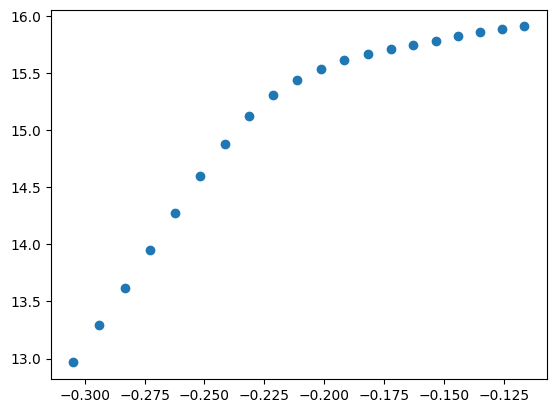

In [53]:
import matplotlib.pyplot as plt
import pwlf


logx = np.log(x)
logy = np.log(y)
plt.scatter(np.log(x), np.log(y))

my_pwlf = pwlf.PiecewiseLinFit(logx, logy)


# fit the data for four line segments
res = my_pwlf.fit(4)

print(res, "\n", logx)


Точки излома (в логарифмической шкале): [-0.30481821 -0.23534027 -0.19867415 -0.11661205]
Пороги в исходной шкале: [0.73725739 0.79030189 0.81981699 0.88993037]


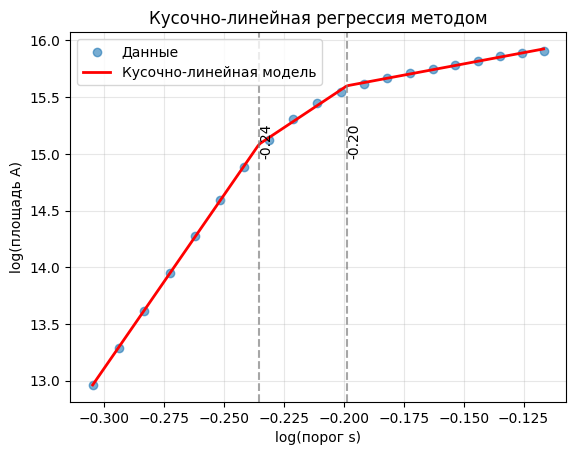


Наклоны сегментов: [30.54848256 14.02659265  3.95783958]
Свободные члены сегментов: [22.27523683 18.38697081 16.3865699 ]


In [55]:
import numpy as np
import matplotlib.pyplot as plt
import pwlf

# Исходные данные x и y (пороги и площади)
# Например:
# x = ... (массив порогов)
# y = ... (массив площадей)

logx = np.log(x)
logy = np.log(y)

# Визуализация исходных точек
plt.scatter(logx, logy, label='Данные', alpha=0.6)

# Создаем модель
my_pwlf = pwlf.PiecewiseLinFit(logx, logy)

# Задаем число сегментов (можно подобрать оптимальное, но для примера фиксируем)
n_segments = 3  # например, 4 сегмента -> 3 точки перегиба
breaks = my_pwlf.fit(n_segments)

# Выводим информацию
print("Точки излома (в логарифмической шкале):", breaks)
print("Пороги в исходной шкале:", np.exp(breaks))

# Предсказываем значения модели на всей области для построения графика
x_plot = np.linspace(logx.min(), logx.max(), 200)
y_plot = my_pwlf.predict(x_plot)

# Рисуем аппроксимирующую ломаную
plt.plot(x_plot, y_plot, 'r-', linewidth=2, label='Кусочно-линейная модель')

# Отмечаем вертикальные линии в точках излома (внутренних)
for b in breaks[1:-1]:
    plt.axvline(b, color='gray', linestyle='--', alpha=0.7)
    plt.text(b, plt.ylim()[1]*0.95, f'{b:.2f}', rotation=90, verticalalignment='top')

# Подписи
plt.xlabel('log(порог s)')
plt.ylabel('log(площадь A)')
plt.title('Кусочно-линейная регрессия методом')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Можно также вывести коэффициенты каждого сегмента (наклоны и пересечения)
# Коэффициенты можно получить через my_pwlf.slopes и my_pwlf.intercepts
print("\nНаклоны сегментов:", my_pwlf.slopes)
print("Свободные члены сегментов:", my_pwlf.intercepts)

In [46]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression

# Ваши данные
logx = np.log(x).reshape(-1, 1)
logy = np.log(y)

# 1. Вычисляем производную (наклон)
dys = np.gradient(logy, logx.flatten())

# 2. Дерево решений для группировки по наклону
n_segments = 3  # Желаемое количество сегментов
tree = DecisionTreeRegressor(max_leaf_nodes=n_segments)
tree.fit(logx, dys)

# Получаем маску для каждого сегмента
segments = tree.apply(logx)

# 3. Обучаем линейную регрессию для каждого сегмента
for segment_id in np.unique(segments):
    mask = segments == segment_id
    X_seg = logx[mask]
    y_seg = logy[mask]
    
    lr = LinearRegression()
    lr.fit(X_seg, y_seg)
    print(f"Сегмент {segment_id}: наклон={lr.coef_[0]:.2f}")

Сегмент 2: наклон=-34.64
Сегмент 3: наклон=-4.47
Сегмент 4: наклон=-15.97


Сегмент 2: наклон=-34.64, свободный член=8.94, диапазон x: [-0.14, -0.12]
Сегмент 3: наклон=-4.47, свободный член=14.57, диапазон x: [-0.30, -0.25]
Сегмент 4: наклон=-15.97, свободный член=11.69, диапазон x: [-0.24, -0.15]


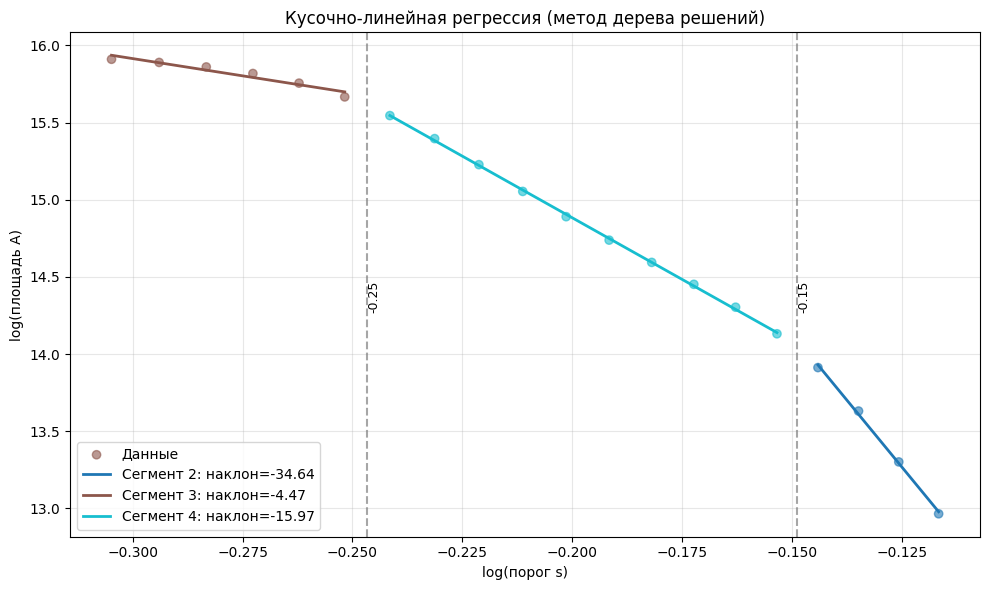


Точки перегиба (в логарифмической шкале): [np.float32(-0.24661455), np.float32(-0.14873551)]
Пороги s (исходная шкала): [0.7814418  0.86179703]


Оптимальное число сегментов по BIC: 4
Найденные перегибы (в исходной шкале порогов s): [0.00405374 0.00415106 0.27174247]
В логарифмической шкале: [-5.50811438 -5.48439193 -1.30290047]


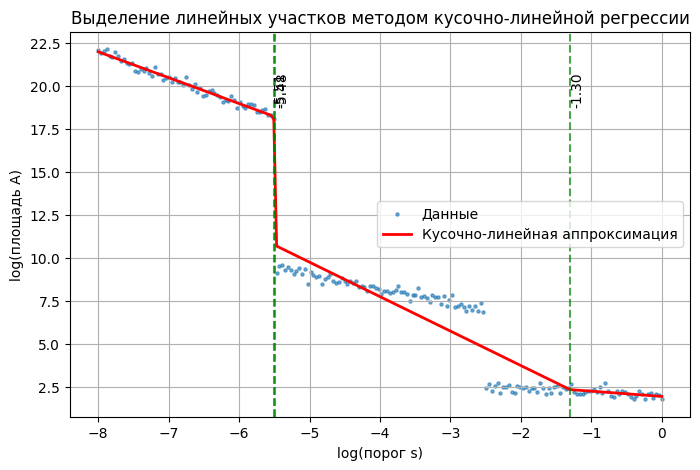

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import pwlf

def find_breaks(logx, logy, max_breaks=3, n_breaks=None):
    """
    Находит точки перегиба (breaks) на кривой logx vs logy.
    
    Параметры:
        logx : array-like, логарифмы порогов (x)
        logy : array-like, логарифмы площадей (y)
        max_breaks : int, максимальное количество перегибов (по умолчанию 3 -> 4 сегмента)
        n_breaks : int или None, если задано, фиксирует количество перегибов
    
    Возвращает:
        breaks : список значений x (в исходной шкале порогов), соответствующих перегибам
        fitted : объект pwlf с результатами аппроксимации
    """
    # Убедимся, что x отсортированы по возрастанию (pwlf требует этого)
    idx = np.argsort(logx)
    x_sorted = logx[idx]
    y_sorted = logy[idx]
    
    # Инициализация модели
    my_pwlf = pwlf.PiecewiseLinFit(x_sorted, y_sorted)
    
    if n_breaks is None:
        # Автоматический выбор оптимального числа сегментов по BIC
        # Перебираем от 1 до max_breaks+1 сегментов (т.е. от 0 до max_breaks перегибов)
        bic = []
        models = []
        for n_seg in range(1, max_breaks + 2):  # n_seg = число сегментов
            breaks = my_pwlf.fit(n_seg)
            models.append((n_seg, breaks))
            y_pred = my_pwlf.predict(x_sorted)
            rss = np.sum((y_sorted - y_pred) ** 2)
            n_params = n_seg + 1  # число параметров: наклоны + точки излома? На самом деле для кусочно-линейной с n_seg сегментами число параметров = n_seg*2 - (n_seg-1)? Упростим: BIC = n * log(RSS/n) + (n_seg+1)*log(n)
            bic.append(len(x_sorted) * np.log(rss / len(x_sorted)) + (n_seg + 1) * np.log(len(x_sorted)))
        # Выбираем модель с минимальным BIC
        best_idx = np.argmin(bic)
        best_n_seg = best_idx + 1
        print(f"Оптимальное число сегментов по BIC: {best_n_seg}")
        # Переобучаем с этим числом сегментов
        breaks = my_pwlf.fit(best_n_seg)
    else:
        # Заданное число перегибов => число сегментов = n_breaks + 1
        breaks = my_pwlf.fit(n_breaks + 1)
    
    # Точки перегиба в исходной шкале (экспонента от logx)
    # breaks содержит границы сегментов; нас интересуют внутренние точки (исключаем минимум и максимум)
    # my_pwlf.fit возвращает массив включая крайние точки, поэтому берём с 1 до -1
    breaks_original = np.exp(breaks[1:-1])  # значения порогов s
    return breaks_original, my_pwlf

# Пример использования
if __name__ == "__main__":
    # Допустим, у вас есть данные x (пороги) и y (площади)
    # Сгенерируем синтетические данные с двумя перегибами
    np.random.seed(42)
    n_points = 200
    # Логарифмы порогов
    logx = np.linspace(-8, 0, n_points)
    # Три линейных сегмента с разными наклонами
    true_breaks_log = [-5.5, -2.5]  # точки перегиба в лог-шкале
    # Определим функцию ломаной
    def piecewise_log(logx):
        y = np.zeros_like(logx)
        # Первый сегмент (крутой наклон)
        mask1 = logx <= true_breaks_log[0]
        y[mask1] = -1.5 * logx[mask1] + 10
        # Второй сегмент (средний наклон)
        mask2 = (logx > true_breaks_log[0]) & (logx <= true_breaks_log[1])
        y[mask2] = -0.8 * logx[mask2] + 5
        # Третий сегмент (пологий наклон)
        mask3 = logx > true_breaks_log[1]
        y[mask3] = -0.2 * logx[mask3] + 2
        return y
    
    logy_true = piecewise_log(logx)
    # Добавим немного шума
    logy = logy_true + np.random.normal(0, 0.2, size=n_points)
    
    # Ищем перегибы (максимум 3 перегиба, пусть алгоритм сам выберет)
    breaks, model = find_breaks(logx, logy, max_breaks=3)
    print("Найденные перегибы (в исходной шкале порогов s):", breaks)
    print("В логарифмической шкале:", np.log(breaks))
    
    # Строим график
    plt.figure(figsize=(8, 5))
    plt.scatter(logx, logy, s=5, label="Данные", alpha=0.6)
    
    # Предсказанные значения по модели
    x_sorted = np.sort(logx)
    y_pred = model.predict(x_sorted)
    plt.plot(x_sorted, y_pred, 'r-', linewidth=2, label="Кусочно-линейная аппроксимация")
    
    # Отмечаем точки перегиба
    for b in np.log(breaks):
        plt.axvline(b, color='green', linestyle='--', alpha=0.7)
        plt.text(b, plt.ylim()[1]*0.9, f'{b:.2f}', rotation=90, verticalalignment='top')
    
    plt.xlabel("log(порог s)")
    plt.ylabel("log(площадь A)")
    plt.legend()
    plt.grid(True)
    plt.title("Выделение линейных участков методом кусочно-линейной регрессии")
    plt.show()